In [1]:
from pathlib import Path

import lasio 
import geopandas as gpd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture

In [2]:
# Input and output paths
ROOT = Path().resolve().parent
RAW  = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed' 
OUTPUT = ROOT / 'output'
OUTPUT.mkdir(parents=True, exist_ok=True)

In [3]:
# Clean dataset
raw_data = pd.read_csv(PROCESSED / "target_lithologies_filled.csv")
raw_data.info()

# Utrecht boundaries
utrecht_city = gpd.read_file(PROCESSED / 'utrecht_city.gpkg')
utrecht_province = gpd.read_file(PROCESSED / 'utrecht_province.gpkg')

<class 'pandas.DataFrame'>
RangeIndex: 4035 entries, 0 to 4034
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                4035 non-null   str    
 1   easting                4035 non-null   float64
 2   northing               4035 non-null   float64
 3   depth_tvd_m            4035 non-null   float64
 4   porosity_pct           4035 non-null   float64
 5   gamma_ray_api          4035 non-null   float64
 6   bulk_density_gcc       4035 non-null   float64
 7   formation_thickness_m  4035 non-null   float64
 8   formation_top_tvd      4035 non-null   float64
 9   formation_base_tvd     4035 non-null   float64
 10  distance_to_usp_km     4035 non-null   float64
dtypes: float64(10), str(1)
memory usage: 346.9 KB


In [4]:
df = raw_data.copy()
well_list = df["well_id"].unique().tolist()

# Wells and Coordinates Dictionary
wells = {
    row["well_id"]: (row["easting"], row["northing"])
    for _, row in df.iterrows()
}

## Geothermal Reservoir Quality Assessment

$$ Baseline RQI = w_{1}\phi + w_{2}h + w_{3}T + w_{4}k - w_{5}GR - w_{6}D$$

### Temperature

In [5]:
dfs_las = {}

for well in well_list:
    las = lasio.read(RAW / f"{well}.las")
    
    df_las = las.df().reset_index()
    dfs_las[well] = df_las

    print(f"\n=========================================")
    print(f"Well Name: {well}")
    print(f"DataFrame Shape: {df_las.shape}")
    print(f"=========================================")
    
    print("--- HEADER METADATA ---")
    for item in las.well:
        print(f"{item.mnemonic:<10} | {item.descr:<40} : {item.value}")



Well Name: EVD-01
DataFrame Shape: (21569, 5)
--- HEADER METADATA ---
STRT       | First Index Value                        : 2196.9004
STOP       | Last Index Value                         : 40.1002
STEP       | Frame Spacing                            : -0.1
NULL       | Absent Value                             : -999.25
WELL       | Well Name                                : EVERDINGEN-01
FLD        | Field Name                               : UNKNOWN
CNTY       | County                                   : 
STAT       | State                                    : 
CTRY       | Country                                  : 
LOC        | Location                                 : 
API        | API Number                               : 
DATE       | Date                                     : 
COMP       | Company Name                             : NAM
SRVC       | Service Company                          : 

Well Name: PKP-01
DataFrame Shape: (27508, 6)
--- HEADER METADATA ---
STRT      

$$\text{Geothermal Gradient Model for Temperature}$$

$$ T(z) = T_s + G \cdot z $$

where,
- z = True vertical depth
- T(z) = Temperature at depth, z
- T(s) = Temperature at surface
- G = Geothermal Gradient

#### BLT-derived Gradient

In [6]:
# Netherlands mean annual surface temperature
surface_temp_c = 10.0

# From BLT-01 Header Information
blt_bht = 167
blt_strt = 0
blt_tdl = 2123.8

# Fahrenheit to Celcius
blt_bht_c = (blt_bht - 32) / 1.8

blt_gradient = (blt_bht_c - surface_temp_c) / (blt_tdl/1000 - blt_strt) 

print(blt_gradient)

30.605518410396456


In [7]:
# BLT-derived gradient is consistent with regional geothermal gradient of Netherlands (31ºC per km)
default_gradient = 31 / 1000

df["temp_est_c"] = surface_temp_c + default_gradient * df["depth_tvd_m"]

## Permeability

In [8]:
# ThermoGIS grids for Permeability from TNO
ds = xr.open_dataset(RAW / "ROSL_ROSLU_permeability_p50.nc")

perms = {}
for name, (x, y) in wells.items():
    val = ds["data"].sel(x=x, y=y, method="nearest").round(0).values.item()
    perms[name] = val

print(perms)

{'EVD-01': 6.0, 'PKP-01': 1.0, 'BLT-01': 82.0, 'JUT-01': 40.0}


In [9]:
df["permeability_p50"] = df["well_id"].map(perms)
df["k_log"] = np.log(df["permeability_p50"])

## Entropy Weight Method (EWM) 

In [10]:
well_agg = df.groupby("well_id").agg(
    phi=("porosity_pct", "mean"),           
    h=("formation_thickness_m", "first"),
    t=("temp_est_c", "mean"),
    k=("k_log", "first"),
    gr=("gamma_ray_api", "mean"),
    d=("depth_tvd_m", "mean"),
    easting=("easting", "first"),
    northing=("northing", "first"),
).reset_index()

### Entropy Weight Method (EWM) Formulation

**1. Min-Max Normalization**
For alternative $i \in \{1, \dots, m\}$ and criterion $j$:

* **Benefit Criteria:**
  $$r_{ij} = \frac{x_{ij} - \min(x_{j})}{\max(x_{j}) - \min(x_{j}) + \epsilon}$$

* **Cost Criteria:**
  $$r_{ij} = \frac{\max(x_{j}) - x_{ij}}{\max(x_{j}) - \min(x_{j}) + \epsilon}$$

*(where $\epsilon = 10^{-12}$ prevents division by zero)*

**2. Proportion Matrix ($P_{ij}$)**
$$p_{ij} = \frac{r_{ij} + \epsilon}{\sum_{i=1}^{m} (r_{ij} + \epsilon)}$$

**3. Shannon Entropy ($e_j$)**
$$e_j = -k \sum_{i=1}^{m} p_{ij} \ln(p_{ij}) \quad \text{where } k = \frac{1}{\ln(m)}$$

**4. Diversification & Weights ($w_j$)**
$$d_j = 1 - e_j \implies w_j = \frac{d_j}{\sum_{j=1}^{n} d_j}$$

In [11]:
def entropy_weights(df, benefit_cols, cost_cols):
    X = df[benefit_cols + cost_cols].copy()
    m = len(X)

    # Normalization
    norm = pd.DataFrame(index=X.index)
    for col in benefit_cols:
        norm[col] = (X[col] - X[col].min()) / (X[col].max() - X[col].min() + 1e-12)
    for col in cost_cols:
        norm[col] = (X[col].max() - X[col]) / (X[col].max() - X[col].min() + 1e-12)

    eps = 1e-12
    P = (norm + eps) / (norm + eps).sum(axis=0)

    # Shannon entropy per indicator
    k_const = 1 / np.log(m)
    entropy = -k_const * (P * np.log(P)).sum(axis=0)

    # weight = degree of diversification (1 - entropy), normalized to sum to 1
    diversification = 1 - entropy
    weights = diversification / diversification.sum()

    return weights, norm

In [12]:
weights, norm = entropy_weights(
    well_agg,
    benefit_cols=["phi", "h", "t", "k"],
    cost_cols=["gr", "d"]                  
)

print("Entropy-derived weights:")
print(weights.round(2).sort_values(ascending=False))

Entropy-derived weights:
phi    0.27
t      0.18
h      0.17
k      0.13
gr     0.13
d      0.12
dtype: float64


#### Simple Additive Weighting (SAW)

In [13]:
well_agg["ewm_quality_score"] = (norm * weights).sum(axis=1)
print("\nRanked wells:")
print(well_agg[["well_id", "ewm_quality_score"]].sort_values("ewm_quality_score", ascending=False))


Ranked wells:
  well_id  ewm_quality_score
0  BLT-01           0.753120
2  JUT-01           0.655506
1  EVD-01           0.338758
3  PKP-01           0.183720


#### TOPSIS (Technique for Order Preference by Similarity to Ideal Solution)

#### TOPSIS Formulation

Score wells by geometric distance to an ideal ("best possible") and anti-ideal ("worst possible")
alternative rather than a weighted sum.

**1. Vector Normalization**
$$r_{ij} = \frac{x_{ij}}{\sqrt{\sum_{i=1}^{m} x_{ij}^2}}$$

**2. Weighted Normalized Matrix**
$$v_{ij} = w_j \cdot r_{ij}$$

**3. Ideal Best / Ideal Worst**
For benefit criteria: best = max, worst = min. For cost criteria: best = min, worst = max.

**4. Separation Measures**
$$D_i^{+} = \sqrt{\sum_j (v_{ij} - v_j^{+})^2} \qquad D_i^{-} = \sqrt{\sum_j (v_{ij} - v_j^{-})^2}$$

**5. Closeness Coefficient**
$$C_i = \frac{D_i^{-}}{D_i^{+} + D_i^{-} + \epsilon}$$
Higher $C_i$ = closer to ideal = higher rank.

In [14]:
def topsis(df, benefit_cols, cost_cols, weights):
    cols = benefit_cols + cost_cols
    X = df[cols].copy()

    # Vector normalization
    r = X / np.sqrt((X ** 2).sum())
    v = r.mul(weights.reindex(cols), axis=1)

    ideal_best = pd.Series(index=cols, dtype=float)
    ideal_worst = pd.Series(index=cols, dtype=float)
    for col in benefit_cols:
        ideal_best[col] = v[col].max()
        ideal_worst[col] = v[col].min()
    for col in cost_cols:
        ideal_best[col] = v[col].min()
        ideal_worst[col] = v[col].max()

    dist_best = np.sqrt(((v - ideal_best) ** 2).sum(axis=1))
    dist_worst = np.sqrt(((v - ideal_worst) ** 2).sum(axis=1))

    eps = 1e-12
    closeness = dist_worst / (dist_best + dist_worst + eps)
    return closeness


In [15]:
well_agg["topsis_quality_score"] = topsis(
    well_agg,
    benefit_cols=["phi", "h", "t", "k"],
    cost_cols=["gr", "d"],
    weights=weights,
).values

print("TOPSIS ranking:")
print(
    well_agg[["well_id", "topsis_quality_score"]]
    .sort_values("topsis_quality_score", ascending=False)
)

TOPSIS ranking:
  well_id  topsis_quality_score
0  BLT-01              0.776593
2  JUT-01              0.707752
1  EVD-01              0.389419
3  PKP-01              0.124528


## Unsupervised Clustering

In [16]:
feature_cols = ["porosity_pct", "formation_thickness_m", "temp_est_c", "k_log", "gamma_ray_api", "depth_tvd_m"]
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

well_features = df.groupby("well_id")[feature_cols].mean()
n_wells = len(well_features)

well_scaler = StandardScaler()
well_X_scaled = well_scaler.fit_transform(well_features)

print(f"Clustering will be performed on {n_wells} wells: {list(well_features.index)}")

Clustering will be performed on 4 wells: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']


### Principal Component Analysis (PCA)

In [17]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

print("Explained variance ratio per component:")
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {var:.3f} ({var*100:.1f}% of variance)")
print(f"\nTotal variance captured by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Explained variance ratio per component:
  PC1: 0.646 (64.6% of variance)
  PC2: 0.278 (27.8% of variance)

Total variance captured by PC1 + PC2: 92.4%


In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_cols
).round(3)

loadings

,PC1,PC2
porosity_pct,-0.256,0.583
formation_thickness_m,-0.433,0.342
temp_est_c,0.463,0.296
k_log,-0.438,0.350
gamma_ray_api,0.354,0.495
depth_tvd_m,0.463,0.296


In [19]:
favorable_corr = np.corrcoef(X_pca[:, 0], df["porosity_pct"])[0, 1]
pc1_sign = -1 if favorable_corr < 0 else 1

df["PC1_quality"] = pc1_sign * df["PC1"]
print(f"Correlation of raw PC1 with porosity: {favorable_corr:.3f}")
print(f"PC1 sign flipped for quality scoring: {pc1_sign == -1}")

Correlation of raw PC1 with porosity: -0.504
PC1 sign flipped for quality scoring: True


In [20]:
well_pca_quality = (
    df.groupby("well_id")["PC1_quality"]
    .mean()
    .rename("pca_quality_score")
    .reset_index()
)
well_pca_quality.sort_values(by="pca_quality_score", ascending=False)

,well_id,pca_quality_score
2,JUT-01,2.021484
0,BLT-01,0.738111
1,EVD-01,-0.145585
3,PKP-01,-3.867225


### K- Means Clustering

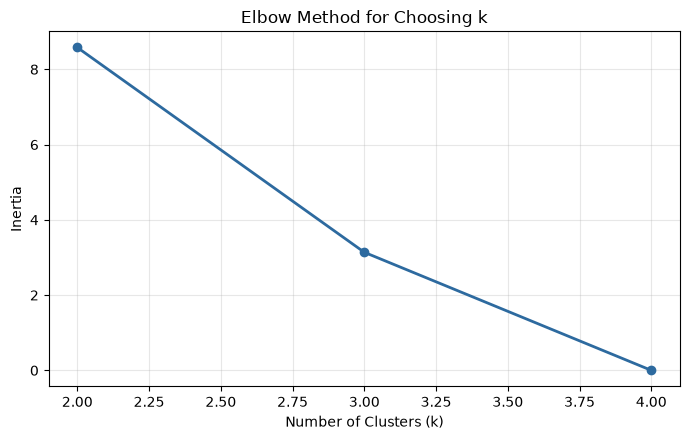

k=2: inertia=8.6
k=3: inertia=3.1
k=4: inertia=0.0


In [21]:
k_range = range(2, n_wells + 1)

inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(well_X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(list(k_range), inertias, marker="o", color="#2d6a9f", linewidth=2)
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method for Choosing k")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f"k={k}: inertia={inertia:.1f}")

In [22]:
weighted_norm_features = norm.mul(weights, axis=1)

for k in [2, 3]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    well_agg["kmeans_cluster"] = kmeans.fit_predict(weighted_norm_features)

    print(f"\nK-Means Cluster Assignments {k} clusters:")
    print(
        well_agg[["well_id", "ewm_quality_score", "kmeans_cluster"]].sort_values(
            "ewm_quality_score", ascending=False
        )
    )


K-Means Cluster Assignments 2 clusters:
  well_id  ewm_quality_score  kmeans_cluster
0  BLT-01           0.753120               1
2  JUT-01           0.655506               1
1  EVD-01           0.338758               0
3  PKP-01           0.183720               0

K-Means Cluster Assignments 3 clusters:
  well_id  ewm_quality_score  kmeans_cluster
0  BLT-01           0.753120               2
2  JUT-01           0.655506               1
1  EVD-01           0.338758               0
3  PKP-01           0.183720               0


### Gaussian Mixture Clustering (GMM)

In [23]:
n_components = min(4, max(2, n_wells - 1))

bgm = BayesianGaussianMixture(
    n_components=n_components,
    covariance_type="full",
    weight_concentration_prior_type="dirichlet_process",
    n_init = 10,
    random_state=42,
    max_iter=500,
)

well_gmm_labels = bgm.fit_predict(well_X_scaled)
well_features["GMM_Cluster"] = well_gmm_labels
df["GMM_Cluster"] = df["well_id"].map(well_features["GMM_Cluster"])

effective_components = int(np.sum(bgm.weights_ > 0.01))
print(f"Bayesian Gaussian Mixture clustered {n_wells} wells")
print(f"Components with non-trivial weight: {effective_components} (of {bgm.n_components} allowed)")
print("\nWell -> GMM cluster assignment:")
print(well_features["GMM_Cluster"])

Bayesian Gaussian Mixture clustered 4 wells
Components with non-trivial weight: 3 (of 3 allowed)

Well -> GMM cluster assignment:
well_id
BLT-01    0
EVD-01    2
JUT-01    0
PKP-01    1
Name: GMM_Cluster, dtype: int64


#### Ranking Summary

In [24]:
def rank_and_classify(scores):
    ranks = scores.rank(method="min", ascending=False).astype(int)
    q1, q2, q3 = scores.quantile([0.25, 0.5, 0.75])
    def classify(s):
        if s <= q1: return "poor"
        elif s <= q2: return "marginal"
        elif s <= q3: return "good"
        else: return "excellent"
    return ranks, scores.apply(classify)

In [25]:
well_quality_lookup = well_agg.set_index("well_id")[["ewm_quality_score", "topsis_quality_score"]]
well_features[["ewm_quality_score", "topsis_quality_score"]] = well_quality_lookup.reindex(well_features.index)
well_features["pca_quality_score"] = well_pca_quality.set_index("well_id")["pca_quality_score"].reindex(well_features.index)

In [26]:
well_features["ewm_quality_rank"], well_features["ewm_quality_class"] = rank_and_classify(well_features["ewm_quality_score"])
well_features["topsis_quality_rank"], well_features["topsis_quality_class"] = rank_and_classify(well_features["topsis_quality_score"])
well_features["pca_quality_rank"], well_features["pca_quality_class"] = rank_and_classify(well_features["pca_quality_score"])

quality_comparison = well_features[["ewm_quality_score","ewm_quality_class","topsis_quality_score", "topsis_quality_class", "pca_quality_score", "pca_quality_class"]]
quality_comparison

,ewm_quality_score,ewm_quality_class,topsis_quality_score,topsis_quality_class,pca_quality_score,pca_quality_class
well_id,,,,,,
BLT-01,0.753120,excellent,0.776593,excellent,0.738111,good
EVD-01,0.338758,marginal,0.389419,marginal,-0.145585,marginal
JUT-01,0.655506,good,0.707752,good,2.021484,excellent
PKP-01,0.183720,poor,0.124528,poor,-3.867225,poor


- EWM-SAW, EWM-TOPSIS and PCA both rank BLT-01 and JUT-01 as the top two wells by composite quality score, with BLT-01 scoring higher under EWM and TOPSIS, and JUT-01 scoring higher under PCA
- All methods rank PKP-01 lowest and EVD-01 in the marginal range
- K-Means and Bayesian Gaussian Mixture clustering were used as an exploratory check of multivariate similarity between wells, not as a ranking method

### Sensitivity Analysis

### 1. Weight Perturbation (Monte Carlo)

In [27]:
def weight_perturbation_sensitivity(well_agg, norm, weights, pct=0.2, n_trials=500, seed=42):
    rng = np.random.default_rng(seed)
    well_ids = well_agg["well_id"].values
    rank_records = []

    for _ in range(n_trials):
        noise = rng.uniform(1 - pct, 1 + pct, size=len(weights))
        perturbed = weights * noise
        perturbed = perturbed / perturbed.sum()

        score = (norm * perturbed).sum(axis=1)
        ranks = score.rank(method="min", ascending=False)
        rank_records.append(ranks.values)

    return pd.DataFrame(rank_records, columns=well_ids)

In [28]:
rank_matrix = weight_perturbation_sensitivity(well_agg, norm, weights, pct=0.2, n_trials=500)

rank_summary = pd.DataFrame({
    "mean_rank": rank_matrix.mean(),
    "std_rank": rank_matrix.std(),
    "min_rank": rank_matrix.min(),
    "max_rank": rank_matrix.max(),
}).sort_values("mean_rank")

print("Rank stability under +/-20% weight perturbation (500 trials):")
print(rank_summary.round(2))

Rank stability under +/-20% weight perturbation (500 trials):
        mean_rank  std_rank  min_rank  max_rank
BLT-01        1.0       0.0       1.0       1.0
JUT-01        2.0       0.0       2.0       2.0
EVD-01        3.0       0.0       3.0       3.0
PKP-01        4.0       0.0       4.0       4.0


### 2. Weighting-Method Comparison

In [29]:
def critic_weights(df, benefit_cols, cost_cols):
    """CRITIC weighting: combines each criterion's variability (std) with how
    uncorrelated it is with the other criteria (1 - correlation), so redundant
    criteria get down-weighted relative to entropy weighting."""
    X = df[benefit_cols + cost_cols].copy()

    norm = pd.DataFrame(index=X.index)
    for col in benefit_cols:
        norm[col] = (X[col] - X[col].min()) / (X[col].max() - X[col].min() + 1e-12)
    for col in cost_cols:
        norm[col] = (X[col].max() - X[col]) / (X[col].max() - X[col].min() + 1e-12)

    std = norm.std()
    corr = norm.corr()
    conflict = (1 - corr).sum()
    info = std * conflict
    weights = info / info.sum()
    return weights, norm

In [30]:
from scipy.stats import spearmanr

benefit_cols = ["phi", "h", "t", "k"]
cost_cols = ["gr", "d"]

equal_weights = pd.Series(1 / len(weights), index=weights.index)
critic_w, critic_norm = critic_weights(well_agg, benefit_cols, cost_cols)

score_entropy = (norm * weights).sum(axis=1)
score_equal = (norm * equal_weights).sum(axis=1)
score_critic = (critic_norm * critic_w).sum(axis=1)

rank_entropy = score_entropy.rank(ascending=False)
rank_equal = score_equal.rank(ascending=False)
rank_critic = score_critic.rank(ascending=False)

method_comparison = pd.DataFrame({
    "well_id": well_agg["well_id"].values,
    "rank_entropy": rank_entropy.values,
    "rank_equal": rank_equal.values,
    "rank_critic": rank_critic.values,
}).sort_values("rank_entropy")

print(method_comparison)

print("\nSpearman rank correlation between weighting methods:")
print(f"  entropy vs equal  : {spearmanr(rank_entropy, rank_equal).correlation:.3f}")
print(f"  entropy vs critic : {spearmanr(rank_entropy, rank_critic).correlation:.3f}")

  well_id  rank_entropy  rank_equal  rank_critic
0  BLT-01           1.0         1.0          1.0
2  JUT-01           2.0         2.0          2.0
1  EVD-01           3.0         3.0          3.0
3  PKP-01           4.0         4.0          4.0

Spearman rank correlation between weighting methods:
  entropy vs equal  : 1.000
  entropy vs critic : 1.000


### 3. Geothermal Gradient Sensitivity

In [31]:
def rescore_with_gradient(df, gradient, benefit_cols, cost_cols):
    df_g = df.copy()
    df_g["temp_est_c"] = surface_temp_c + gradient * df_g["depth_tvd_m"]

    agg = df_g.groupby("well_id").agg(
        phi=("porosity_pct", "mean"),
        h=("formation_thickness_m", "first"),
        t=("temp_est_c", "mean"),
        k=("k_log", "first"),
        gr=("gamma_ray_api", "mean"),
        d=("depth_tvd_m", "mean"),
    ).reset_index()

    w, n = entropy_weights(agg, benefit_cols, cost_cols)
    score = (n * w).sum(axis=1)
    return agg["well_id"].values, score.rank(ascending=False).values

In [32]:
gradients = {
    "-10%": default_gradient * 0.9,
    "baseline": default_gradient,
    "+10%": default_gradient * 1.1,
}

gradient_ranks = {}
for label, g in gradients.items():
    ids, ranks = rescore_with_gradient(df, g, benefit_cols=["phi", "h", "t", "k"], cost_cols=["gr", "d"])
    gradient_ranks[label] = pd.Series(ranks, index=ids)

gradient_comparison = pd.DataFrame(gradient_ranks).sort_values("baseline")
print("Rank under different geothermal gradient assumptions:")
print(gradient_comparison)


Rank under different geothermal gradient assumptions:
        -10%  baseline  +10%
BLT-01   1.0       1.0   1.0
JUT-01   2.0       2.0   2.0
EVD-01   3.0       3.0   3.0
PKP-01   4.0       4.0   4.0


#### Sensitivity Summary

- Ranking does not change after running weight-pertubation trials
- Entropy, equal-weight, and CRITIC weighting agree on the top two wells (BLT-01, JUT-01)
- The ±10% gradient assumption does not change the top two wells (BLT-01, JUT-01)

### Spatial Distribution of Wells

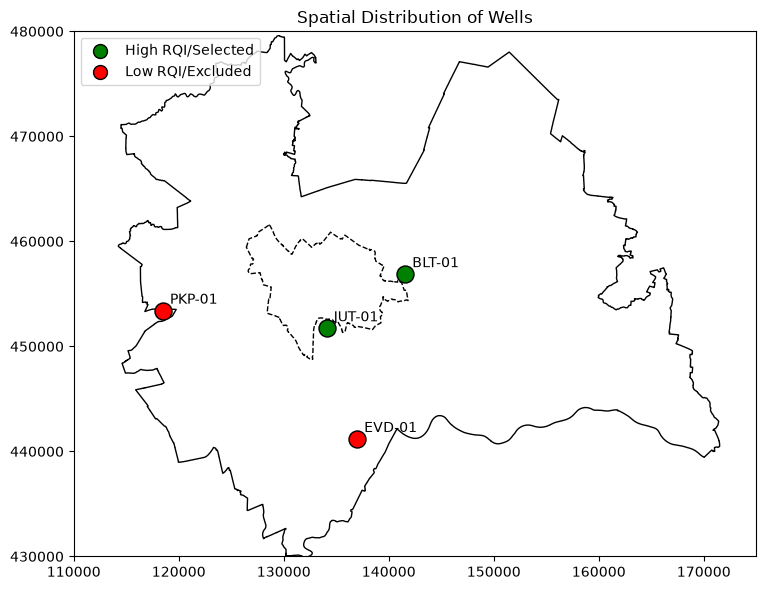

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

utrecht_province.boundary.plot(ax=ax, color="black", linewidth=1)
utrecht_city.boundary.plot(ax=ax, color="black", linewidth=1, linestyle="--")

for name, (x, y) in wells.items():
    color = "green" if name in ["BLT-01", "JUT-01"] else "red"
    ax.scatter(x, y, color=color, edgecolor="black", s=150, zorder=5)
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(5, 5))

ax.scatter(
    [], [], color="green", edgecolor="black", s=100, label="High RQI/Selected"
)
ax.scatter(
    [], [], color="red", edgecolor="black", s=100, label="Low RQI/Excluded"
)

ax.set_xlim(110000, 175000)
ax.set_ylim(430000, 480000)

ax.legend(loc="upper left")
ax.set_title("Spatial Distribution of Wells")
plt.tight_layout()
plt.show()

In [34]:
df_perm = df[df["well_id"].isin(["BLT-01", "JUT-01"])][["well_id", "easting", "northing", "depth_tvd_m", "porosity_pct", "bulk_density_gcc", "formation_thickness_m", "distance_to_usp_km", "temp_est_c", "permeability_p50", "k_log"]].reset_index()
df_perm.info()

<class 'pandas.DataFrame'>
RangeIndex: 2525 entries, 0 to 2524
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  2525 non-null   int64  
 1   well_id                2525 non-null   str    
 2   easting                2525 non-null   float64
 3   northing               2525 non-null   float64
 4   depth_tvd_m            2525 non-null   float64
 5   porosity_pct           2525 non-null   float64
 6   bulk_density_gcc       2525 non-null   float64
 7   formation_thickness_m  2525 non-null   float64
 8   distance_to_usp_km     2525 non-null   float64
 9   temp_est_c             2525 non-null   float64
 10  permeability_p50       2525 non-null   float64
 11  k_log                  2525 non-null   float64
dtypes: float64(10), int64(1), str(1)
memory usage: 236.8 KB


In [35]:
df_perm.to_csv(PROCESSED / "clean_dataset_with_permeability.csv", index=False)